In [10]:
#from google.colab import drive
#drive.mount('/content/drive')

In [11]:
#!mkdir -p /content/butterfly_dataset

In [12]:
#!cp -r "/content/drive/MyDrive/Datasets/Image Dataset/data" /content/butterfly_dataset/

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import os
import sklearn
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import PIL
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
import joblib

In [14]:
print("Pandas Version:", pd.__version__)
print("Scikit-Learn Version", sklearn.__version__)
print("Tensorflow Version", tf.__version__)
print("PIL Version:", PIL.__version__)
print("Seaborn Version", sns.__version__)
print("Joblib Version:", joblib.__version__)

Pandas Version: 2.2.2
Scikit-Learn Version 1.6.1
Tensorflow Version 2.20.0
PIL Version: 11.3.0
Seaborn Version 0.13.2
Joblib Version: 1.5.3


In [15]:
# Colab local disk path
DATA_DIR = Path("/content/butterfly_dataset/data")

# Checking if the dataset already exists on the local disk
if not os.path.exists(DATA_DIR):
    print("Dataset not found on local disk! Copying folder from Google Drive, please wait 1-2 minutes...")
    !mkdir -p /content/butterfly_dataset
    !cp -r "/content/drive/MyDrive/Datasets/Image Dataset/data" /content/butterfly_dataset/
    print("Copy complete! Data is now ready on Colab's super-fast local disk.")
else:
    print("Data already exists on local disk! No need to copy again.")

Dataset not found on local disk! Copying folder from Google Drive, please wait 1-2 minutes...
Copy complete! Data is now ready on Colab's super-fast local disk.


In [16]:
#Current Working Path
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()

#dataset root
DATA_DIR = Path("/content/butterfly_dataset/data")

print("Train folder exists:", os.path.exists(DATA_DIR / "train"))
print("Test folder exists:", os.path.exists(DATA_DIR / "test"))
print("Train csv exists:", os.path.exists(DATA_DIR / "Training_set.csv"))
print("Train csv exists:", os.path.exists(DATA_DIR / "Testing_set.csv"))

Train folder exists: True
Test folder exists: True
Train csv exists: True
Train csv exists: True


In [17]:
#load the training & testing csv dataset
train_df = pd.read_csv(DATA_DIR / "Training_set.csv")
test_df = pd.read_csv(DATA_DIR / "Testing_set.csv")

In [18]:
#image path columns
train_df['image_path'] = train_df['filename'].apply(
    lambda x: os.path.join(DATA_DIR, "train", x)
)

test_df['image_path'] = test_df['filename'].apply(
    lambda x:os.path.join(DATA_DIR, "test", x)
)

In [19]:
train_df.sample(5)

,filename,label,image_path
6341,Image_6342.jpg,CLOUDED SULPHUR,/content/butterfly_dataset/data/train/Image_63...
5517,Image_5518.jpg,PAINTED LADY,/content/butterfly_dataset/data/train/Image_55...
121,Image_122.jpg,BLUE SPOTTED CROW,/content/butterfly_dataset/data/train/Image_12...
639,Image_640.jpg,ELBOWED PIERROT,/content/butterfly_dataset/data/train/Image_64...
172,Image_173.jpg,TROPICAL LEAFWING,/content/butterfly_dataset/data/train/Image_17...


In [20]:
test_df.sample(5)

,filename,image_path
1998,Image_1999.jpg,/content/butterfly_dataset/data/test/Image_199...
322,Image_323.jpg,/content/butterfly_dataset/data/test/Image_323...
1730,Image_1731.jpg,/content/butterfly_dataset/data/test/Image_173...
390,Image_391.jpg,/content/butterfly_dataset/data/test/Image_391...
1756,Image_1757.jpg,/content/butterfly_dataset/data/test/Image_175...


In [21]:
print("Train Shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train Shape: (6499, 3)
Test shape: (2786, 2)


# EDA & validation

In [22]:
#checking NAN values
print(f"NAN Values:\n{train_df.isna().sum()}")
print("-------------")
#checking duplicates
print("Duplicate Values:",train_df.duplicated().sum())
print("Total Species:", train_df['label'].value_counts().shape[0])

NAN Values:
filename      0
label         0
image_path    0
dtype: int64
-------------
Duplicate Values: 0
Total Species: 75


In [23]:
os.makedirs("/content/drive/MyDrive/Datasets/butterfly_classification_project", exist_ok=True)

/tmp/ipykernel_746/2018134790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['label'], palette='Set1')


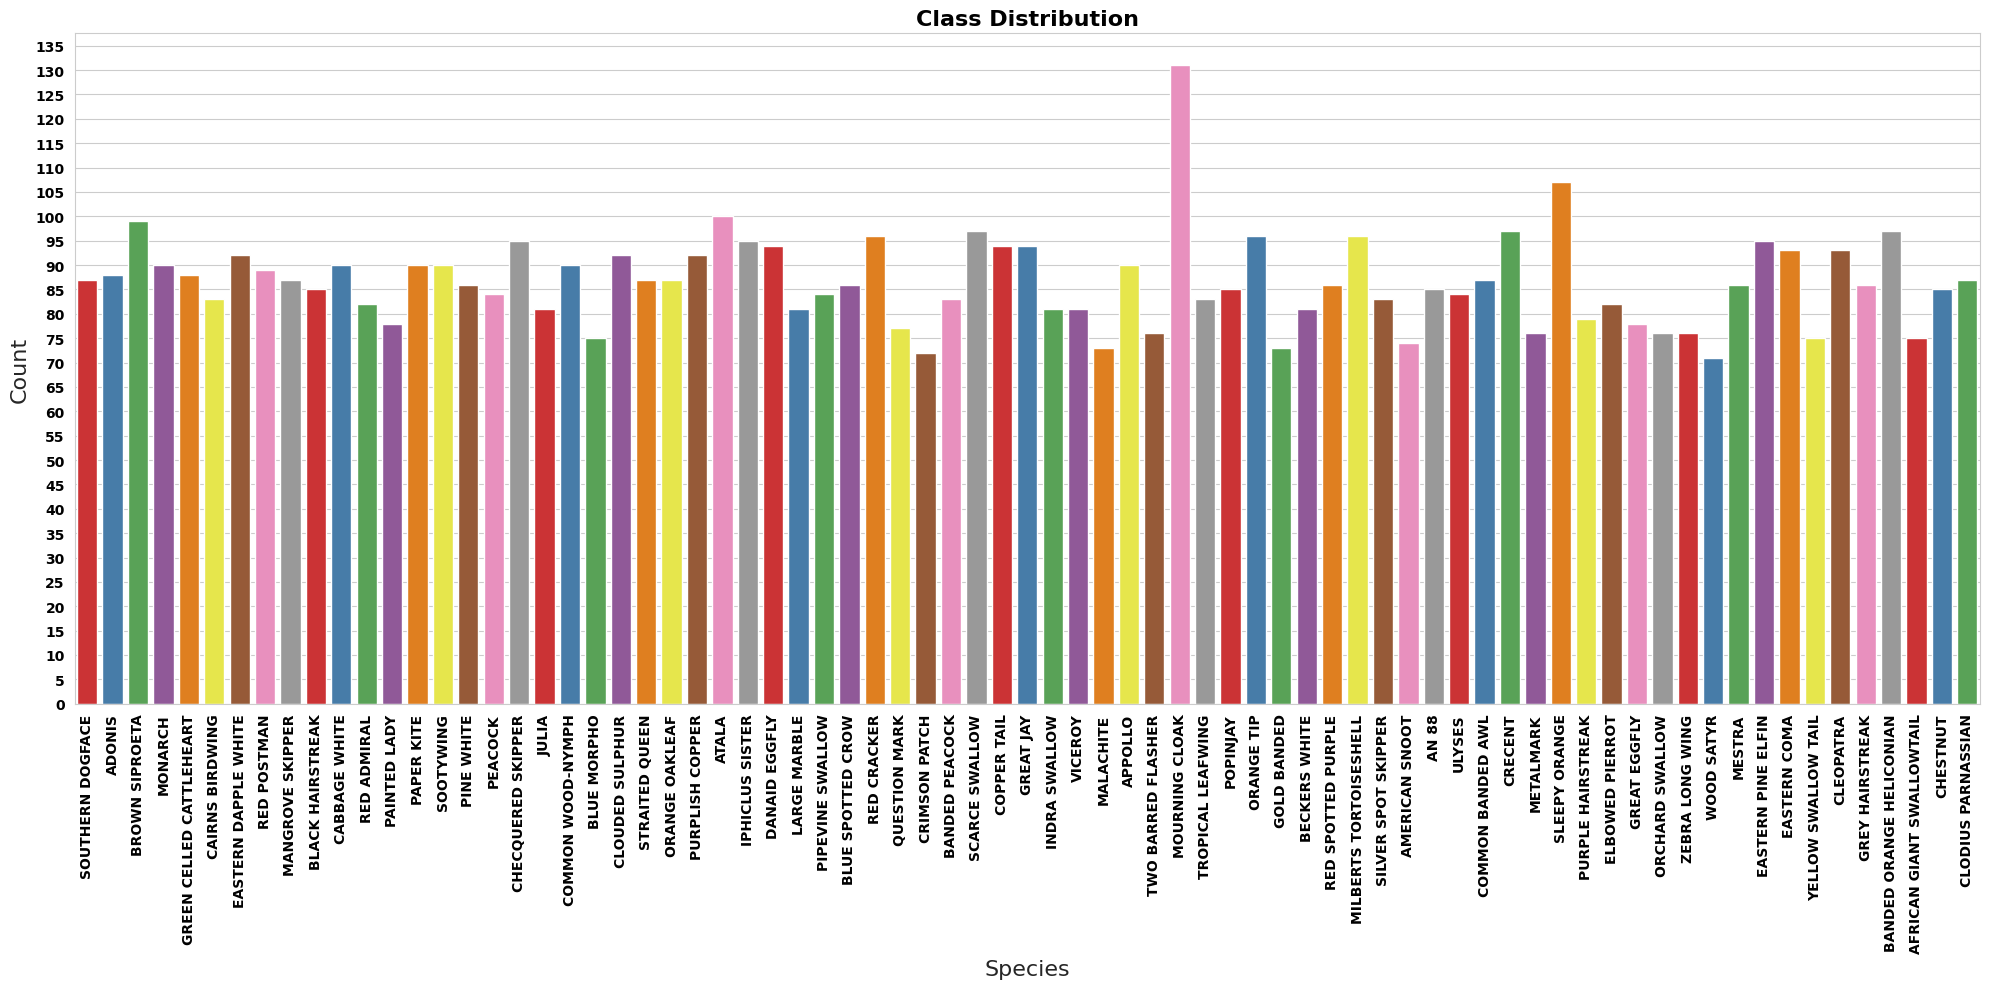

In [24]:
plt.figure(figsize=(20, 10))
sns.set_style('whitegrid')
sns.countplot(x=train_df['label'], palette='Set1')
plt.title("Class Distribution", fontsize=16, color="#000000", weight='bold')
plt.xlabel("Species", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.xticks(rotation=90, color="#000000", weight='bold')
plt.gca().yaxis.set_major_locator(MultipleLocator(5))
plt.yticks(color="#000000", weight='bold')
plt.savefig("/content/drive/MyDrive/Datasets/butterfly_classification_project/class_distribution.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [25]:
# Print the minimum and maximum class frequencies for label column
print(f"Minimum frequency: {train_df['label'].value_counts().min()}")
print(f"Maximum frequency: {train_df['label'].value_counts().max()}")

Minimum frequency: 71
Maximum frequency: 131


Sufficient images in each class; Ok for training

In [26]:
# Check for any missing images by verifying if the paths exist
missing_files = train_df[~train_df['image_path'].apply(os.path.exists)]
print("Missing Count:",len(missing_files))

Missing Count: 0


# Now Real EDA start

In [27]:
#File formate check
valid_ext = (".jpg", ".jpeg", ".png")
invalid_files = []

for path in train_df['image_path']:
    if not path.lower().endswith(valid_ext):
        invalid_files.append(path)

print("Invalid formate images:", len(invalid_files))

Invalid formate images: 0


In [28]:
#RGB/ corruted image check
#corrupted = []
#non_rgb = []

#for path in train_df['image_path']:
#    try:
#        img = Image.open(path)
#
        #check RGB
#        if img.mode != "RGB":
#            non_rgb.append(path)
#
#            img.verify()
#    except:
#        corrupted.append(path)

#print("Corrupted Images:", len(corrupted))
#print("Non RGB:", len(non_rgb))

In [29]:
#small size image checking
small_files = []
for path in train_df['image_path']:
    try:
        size_kb = os.path.getsize(path) / 1024
        if size_kb < 5:
            small_files.append(path)
    except:
        pass

print("Small Files (<5kb):", len(small_files))

Small Files (<5kb): 0


In [30]:
#checking diplicate images
train_files = set(train_df['filename'])

print("Total train images:", len(train_files))
print("unique images:", len(set(train_files)))

Total train images: 6499
unique images: 6499


# Preprocessing

In [31]:
lr = LabelEncoder()
train_df['encoded'] = lr.fit_transform(train_df['label'])

joblib.dump(lr, "/content/drive/MyDrive/Datasets/butterfly_classification_project/label_encoder.joblib")
print("Classes:", lr.classes_[:5])

Classes: ['ADONIS' 'AFRICAN GIANT SWALLOWTAIL' 'AMERICAN SNOOT' 'AN 88' 'APPOLLO']


In [32]:
#Train/Validation split
train_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df['encoded']
)
print("Train size", len(train_df))
print("Val size:", len(val_df))

Train size 5199
Val size: 1300


# Augmentation Layer

In [33]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.Rescaling(1./255)
], name='augmentation')



def load_image_224(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    return img, label

def load_and_augment_224(image_path, label):
    img, label = load_image_224(image_path, label)
    img = augmentation(img, training=True)
    return img, label

In [34]:
train_ds_cnn = (
    tf.data.Dataset.from_tensor_slices(
        (train_df['image_path'].values, train_df['encoded'].values)
    )
    .map(load_and_augment_224, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_cnn = (
    tf.data.Dataset.from_tensor_slices(
        (val_df['image_path'].values, val_df['encoded'].values)
    )
    .map(lambda img_path, label: (layers.Rescaling(1./255)(load_image_224(img_path, label)[0]), label), num_parallel_calls=tf.data.AUTOTUNE) # Normalize validation data
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


test_ds = (
    tf.data.Dataset.from_tensor_slices(
        (test_df['image_path'].values)
    )
    .map(lambda p: layers.Rescaling(1./255)(load_image_224(p, 0)[0]))
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
print("TensorFlow datasets re-created with corrected pipeline.")

TensorFlow datasets re-created with corrected pipeline.


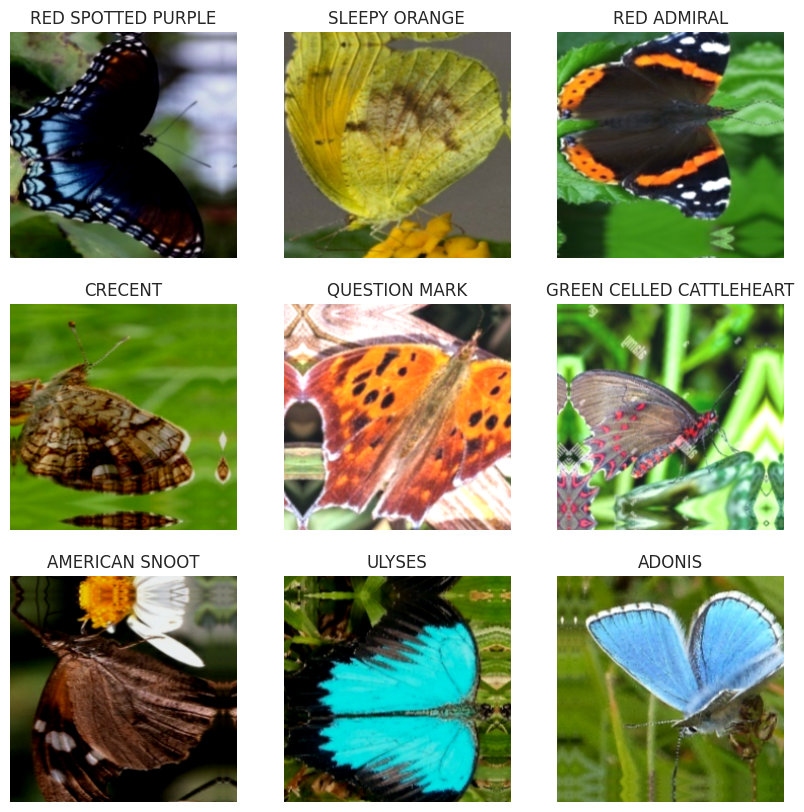

In [35]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds_cnn.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(lr.inverse_transform([labels[i].numpy()])[0])
        plt.axis("off")
plt.show()

In [36]:
total_classes = len(lr.classes_)

base_cnn_sequential = models.Sequential([
    layers.Input(shape=(224, 224, 3), name='input_layer'),

    #Block1
    layers.Conv2D(32, (3, 3), padding='same', use_bias=False, name='conv1_1'),
    layers.BatchNormalization(name='bn1_1'),
    layers.Activation('relu', name='relu1_1'),
    layers.Conv2D(32, (3, 3), padding='same', use_bias=False, name='conv1_2'),
    layers.BatchNormalization(name='bn1_2'),
    layers.Activation('relu', name='relu1_2'),
    layers.MaxPooling2D(2, 2, name='pool1'),
    layers.Dropout(0.1, name='drop1'),

    #Block2
    layers.Conv2D(64, (3, 3), padding='same', use_bias=False, name='conv2_1'),
    layers.BatchNormalization(name='bn2_1'),
    layers.Activation('relu', name='relu2_1'),
    layers.Conv2D(64, (3, 3), padding='same', use_bias=False, name='conv2_2'),
    layers.BatchNormalization(name='bn2_2'),
    layers.Activation('relu', name='relu2_2'),
    layers.MaxPooling2D(2, 2, name='pool2'),
    layers.Dropout(0.1, name='drop2'),

    #Block3
    layers.Conv2D(128, (3, 3), padding='same', use_bias=False, name='conv3_1'),
    layers.BatchNormalization(name='bn3_1'),
    layers.Activation('relu', name='relu3_1'),
    layers.Conv2D(128, (3, 3), padding='same', use_bias=False, name='conv3_2'),
    layers.BatchNormalization(name='bn3_2'),
    layers.Activation('relu', name='relu3_2'),
    layers.MaxPooling2D(2, 2, name='pool3'),
    layers.Dropout(0.2, name='drop3'),

    #Block4
    layers.Conv2D(256, (3, 3), padding='same', use_bias=False, name='conv4_1'),
    layers.BatchNormalization(name='bn4_1'),
    layers.Activation('relu', name='relu4_1'),
    layers.Conv2D(256, (3, 3), padding='same', use_bias=False, name='conv4_2'),
    layers.BatchNormalization(name='bn4_2'),
    layers.Activation('relu', name='relu4_2'),
    layers.MaxPooling2D(2, 2, name='pool4'),
    layers.Dropout(0.3, name='drop4'),

    #Block5
    layers.Conv2D(512, (3, 3), padding='same', use_bias=False, name='conv5_1'),
    layers.BatchNormalization(name='bn5_1'),
    layers.Activation('relu', name='relu5_1'),
    layers.Conv2D(512, (3, 3), padding='same', use_bias=False, name='conv5_2'),
    layers.BatchNormalization(name='bn5_2'),
    layers.Activation('relu', name='relu5_2'),
    layers.MaxPooling2D(2, 2, name='pool5'),
    layers.Dropout(0.3, name='drop5'),

    #Global Average layer
    layers.GlobalAveragePooling2D(name='global_average_pooling'),
    layers.Dense(512, use_bias=False, name='dense_feature'),
    layers.BatchNormalization(name='dense_drop'),
    layers.Activation('relu', name='relu_dense'),
    layers.Dropout(0.5, name='drop6'),

    #output layer
    layers.Dense(total_classes, activation='softmax', name='output_layer'),
], name='base_cnn_sequential')

base_cnn_sequential.summary()

Model: "base_cnn_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (Activation)            │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (Activation)            │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (Activation)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (Activation)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (Activation)            │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (Activation)            │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_1 (Conv2D)                │ (None, 28, 28, 256)    │       294,91

 Total params: 5,020,843 (19.15 MB)

 Trainable params: 5,015,851 (19.13 MB)

 Non-trainable params: 4,992 (19.50 KB)

In [37]:
base_cnn_sequential.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model re-compiled with a lower learning rate.")

Model re-compiled with a lower learning rate.


In [38]:
base_cnn_sequential_callback = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/Datasets/butterfly_classification_project/base_cnn_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=0.0000001,
        verbose=1
    )
]
print("Training callbacks are defined.")

Training callbacks are defined.


In [39]:
base_cnn_model = base_cnn_sequential.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=25,
    callbacks=base_cnn_sequential_callback
)


Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.0427 - loss: 4.5529
Epoch 1: val_accuracy improved from None to 0.01385, saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/base_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/base_cnn_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 163s 716ms/step - accuracy: 0.0675 - loss: 4.2068 - val_accuracy: 0.0138 - val_loss: 5.0713 - learning_rate: 1.0000e-04
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.1295 - loss: 3.6549
Epoch 2: val_accuracy improved from 0.01385 to 0.01615, saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/base_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/base_cnn_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 558ms/step - accuracy: 0.1385 - loss: 3.5650 - val_accuracy: 0.0162 - val_loss: 5.7696

Saaved:/content/drive/MyDrive/Datasets/butterfly_classification_project/efficientnet_performance_graphs.png


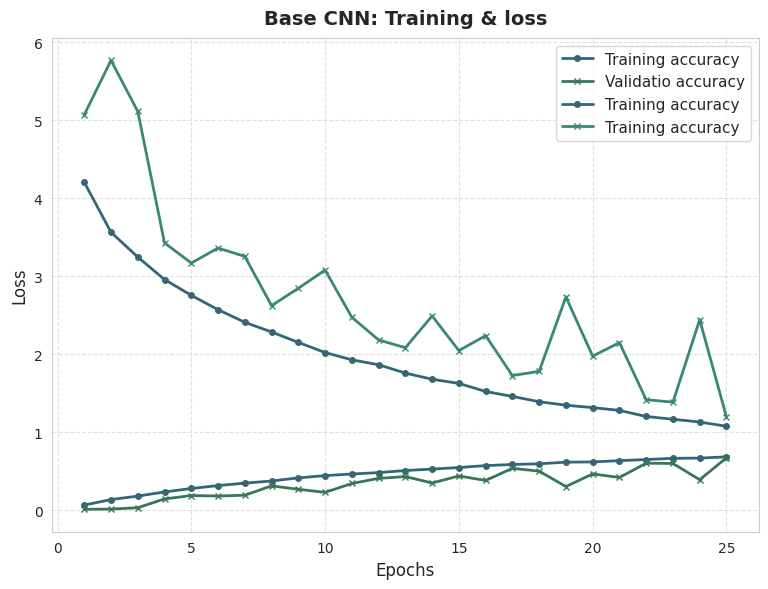

In [40]:
acc_cnn = base_cnn_model.history['accuracy']
val_acc_cnn = base_cnn_model.history['val_accuracy']
loss_cnn = base_cnn_model.history['loss']
val_loss_cnn = base_cnn_model.history['val_loss']
epochs_range_cnn = range(1, len(acc_cnn) + 1)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_cnn, acc_cnn, label='Training accuracy', color='#346678', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range_cnn, val_acc_cnn, label='Validatio accuracy', color='#387658', linewidth=2, marker='x', markersize=4)
plt.title('Base CNN: Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 1)
plt.plot(epochs_range_cnn, loss_cnn, label='Training accuracy', color='#346678', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range_cnn, val_loss_cnn, label='Training accuracy', color='#398778', linewidth=2, marker='x', markersize=4)
plt.title('Base CNN: Training & loss', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

save_dir = "/content/drive/MyDrive/Datasets/butterfly_classification_project"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "efficientnet_performance_graphs.png")

plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saaved:{save_path}")


# ***EfficientNetB0 Model pipeline***

In [41]:
effNet_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(factor=0.1, value_range=(0, 255)),
], name='augmentation')

In [42]:
def load_image_effnet(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32)
    return img, label


def load_and_augment_effnet(image_path, label):
    img, label = load_image_effnet(image_path, label)
    img = effNet_augmentation(img)
    return img, label

In [43]:
train_ds_effnet = (
    tf.data.Dataset.from_tensor_slices(
        (train_df['image_path'].values, train_df['encoded'].values)
    )
    .map(load_and_augment_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds_effnet = (
    tf.data.Dataset.from_tensor_slices(
        (val_df['image_path'].values, val_df['encoded'].values)
    )
    .map(load_image_effnet, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [44]:
effNet_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
effNet_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [45]:
effnet_sequential_model = models.Sequential([
    layers.Input(shape=(224, 224, 3), name='input_layer'),
    effNet_model,
    layers.GlobalAveragePooling2D(name='global_average_effnet'),
    layers.Dropout(0.4, name='frop_effnet_1'),
    layers.Dense(256, activation='relu', name='dense_effnet'),
    layers.Dropout(0.3, name='drop_effnet_2'),
    layers.Dense(total_classes, activation='softmax', name='effnet_output')
], name='EfficientNetB0_Sequential_Butterfly')

In [46]:
efficientne_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/Datasets/butterfly_classification_project/Effnet_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )

]

In [47]:
effnet_sequential_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
effnet_sequential_model.summary()

Model: "EfficientNetB0_Sequential_Butterfly"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_effnet           │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frop_effnet_1 (Dropout)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_effnet (Dense)            │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_effnet_2 (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ effnet_output (Dense)           │ (None, 75)             │        19,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,396,782 (16.77 MB)

 Trainable params: 347,211 (1.32 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [48]:
efficient_history = effnet_sequential_model.fit(
    train_ds_effnet,
    validation_data=val_ds_effnet,
    epochs=40,
    callbacks=efficientne_callbacks
)

Epoch 1/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.2219 - loss: 3.4062
Epoch 1: val_accuracy improved from None to 0.74077, saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/Effnet_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/Effnet_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 569ms/step - accuracy: 0.3914 - loss: 2.5525 - val_accuracy: 0.7408 - val_loss: 1.1091 - learning_rate: 0.0010
Epoch 2/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.6944 - loss: 1.1548
Epoch 2: val_accuracy improved from 0.74077 to 0.81385, saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/Effnet_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Datasets/butterfly_classification_project/Effnet_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 60s 302ms/step - accuracy: 0.7180 - loss: 1.0442 - val_accuracy: 0.8138 - val_loss: 0.6774 - learning_r

Saaved:/content/drive/MyDrive/Datasets/butterfly_classification_project/efficientnet_performance_graphs.png


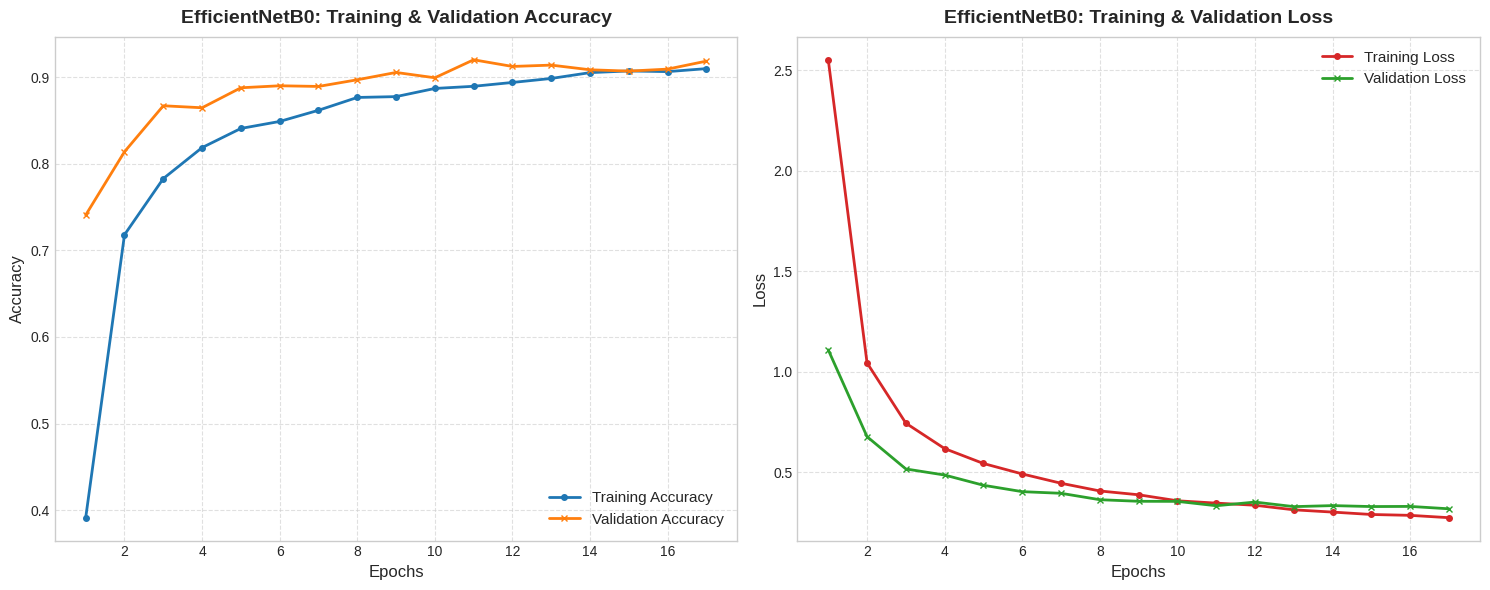

In [49]:
plt.style.use('seaborn-v0_8-whitegrid')

acc = efficient_history.history['accuracy']
val_acc = efficient_history.history['val_accuracy']
loss = efficient_history.history['loss']
val_loss = efficient_history.history['val_loss']
epochs_range = range(1, len(acc) + 1)


plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2, marker='x', markersize=4)
plt.title('EfficientNetB0: Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2, marker='x', markersize=4)
plt.title('EfficientNetB0: Training & Validation Loss', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

save_dir = "/content/drive/MyDrive/Datasets/butterfly_classification_project"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "efficientnet_performance_graphs.png")

plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saaved:{save_path}")


plt.show()